# CC - Saltim: Pipeline de Dados, EDA e Baseline Preditivo

Notebook de implementação da entrega da CC com foco em:
- carregamento dos dados,
- análise exploratória inicial,
- limpeza e transformação,
- tratamento de outliers,
- baseline de previsão semanal de pedidos.

A estrutura segue princípios de reprodutibilidade, modularização e documentação acadêmica.

## 1. Set Up Environment and Dependencies
Instalação/importação de dependências, verificação de versões e inicialização de configurações reprodutíveis.

In [12]:
from __future__ import annotations

import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")

print("Ambiente pronto")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

Ambiente pronto
pandas: 3.0.2
numpy: 2.4.4


## 2. Define Configuration and Constants
Bloco central de configuração com caminhos, parâmetros de tratamento e hiperparâmetros dos baselines.

In [13]:
CONFIG: dict[str, Any] = {
    "project_root": Path.cwd(),
    "data_dir": Path("data"),
    "test_weeks": 16,
    "iqr_multiplier": 1.5,
    "event_exception_cols": ["is_holiday", "is_carnaval", "is_sao_joao", "is_summer"],
    "expected_files": {
        "estoque": "estoque_entradas_sintetico_2023_2026_mar.xlsx",
        "fichas": "fichas_tecnicas_ids.xlsx",
        "ingredientes": "lista_ingredientes.xlsx",
        "receitas": "lista_receitas.xlsx",
        "pedidos": "pedidos_sinteticos_2023_2026_mar.xlsx",
        "resumo_diario": "resumo_diario_pedidos_2023_2026_mar.xlsx",
        "resumo_mensal": "resumo_mensal_pedidos_2023_2026_mar.xlsx",
    },
}

print("Diretório do projeto:", CONFIG["project_root"])
print("Diretório de dados:", CONFIG["data_dir"].resolve())

Diretório do projeto: c:\Users\PC\OneDrive\Área de Trabalho\projetos
Diretório de dados: C:\Users\PC\OneDrive\Área de Trabalho\projetos\data


## 3. Implement Core Data Structures
Definição de dataclasses e estruturas tipadas para transportar dados e resultados de forma clara.

In [14]:
@dataclass
class QualitySummary:
    tabela: str
    linhas: int
    colunas: int
    nulos_total: int
    duplicatas: int


@dataclass
class ModelArtifacts:
    rmse: dict[str, float]
    test_frame: pd.DataFrame
    model: Pipeline


@dataclass
class PipelineState:
    tabelas_raw: dict[str, pd.DataFrame]
    tabelas_clean: dict[str, pd.DataFrame]
    diario: pd.DataFrame
    diario_sem_outliers: pd.DataFrame
    semanal: pd.DataFrame
    outlier_audit: pd.DataFrame
    model_artifacts: ModelArtifacts | None = None

## 4. Build Main Processing Functions
Funções modulares para carregamento, limpeza, transformação, detecção de outliers e modelagem baseline.

In [15]:
def to_snake_case(columns: list[str]) -> list[str]:
    return [
        c.strip()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .lower()
        for c in columns
    ]


def load_tables(config: dict[str, Any]) -> dict[str, pd.DataFrame]:
    tables: dict[str, pd.DataFrame] = {}
    for key, file_name in config["expected_files"].items():
        path = config["data_dir"] / file_name
        if not path.exists():
            raise FileNotFoundError(f"Arquivo não encontrado: {path}")
        df = pd.read_excel(path)
        df.columns = to_snake_case(df.columns.tolist())
        tables[key] = df
    return tables


def build_quality_report(tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    records: list[QualitySummary] = []
    for name, df in tables.items():
        records.append(
            QualitySummary(
                tabela=name,
                linhas=int(df.shape[0]),
                colunas=int(df.shape[1]),
                nulos_total=int(df.isna().sum().sum()),
                duplicatas=int(df.duplicated().sum()),
            )
        )
    return pd.DataFrame([r.__dict__ for r in records]).sort_values("tabela")


def normalize_tables(tables: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    clean = {k: v.copy() for k, v in tables.items()}

    clean["pedidos"]["data_hora"] = pd.to_datetime(clean["pedidos"]["data_hora"], errors="coerce")
    clean["pedidos"] = clean["pedidos"].rename(columns={"id_produto": "id_receita"})
    clean["pedidos"]["id_receita"] = clean["pedidos"]["id_receita"].astype("Int64")
    clean["pedidos"]["quantidade"] = pd.to_numeric(clean["pedidos"]["quantidade"], errors="coerce")

    clean["resumo_diario"]["date"] = pd.to_datetime(clean["resumo_diario"]["date"], errors="coerce")
    clean["estoque"]["data_recebimento"] = pd.to_datetime(clean["estoque"]["data_recebimento"], errors="coerce")
    clean["estoque"]["data_validade"] = pd.to_datetime(clean["estoque"]["data_validade"], errors="coerce")

    clean["fichas"] = clean["fichas"].dropna(subset=["qtd_ingrediente", "custo_ingrediente"])

    for table_name, text_cols in {
        "ingredientes": ["ingrediente", "un_ingrediente"],
        "receitas": ["receita", "tipo"],
    }.items():
        for col in text_cols:
            clean[table_name][col] = clean[table_name][col].astype(str).str.strip().str.upper()

    for name, df in clean.items():
        clean[name] = df.drop_duplicates().reset_index(drop=True)

    clean["pedidos"] = clean["pedidos"].dropna(subset=["data_hora", "id_receita", "quantidade"])
    clean["pedidos"] = clean["pedidos"][clean["pedidos"]["quantidade"] > 0]

    return clean


def create_daily_frame(tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    pedidos = tables["pedidos"].copy()
    resumo_diario = tables["resumo_diario"].copy().rename(columns={"pedidos_dia": "pedidos_dia_resumo"})

    pedidos["date"] = pedidos["data_hora"].dt.floor("D")

    daily = (
        pedidos.groupby("date", as_index=False)
        .agg(
            pedidos_dia=("id_pedido", "nunique"),
            itens_dia=("quantidade", "sum"),
            linhas_itens=("id_pedido", "size"),
        )
        .sort_values("date")
    )

    event_cols = ["date", "pedidos_dia_resumo", "is_holiday", "is_carnaval", "is_sao_joao", "is_summer"]
    daily = daily.merge(resumo_diario[event_cols], on="date", how="left")

    for col in ["is_holiday", "is_carnaval", "is_sao_joao", "is_summer"]:
        daily[col] = daily[col].fillna(0).astype(int)

    daily["diff_resumo"] = daily["pedidos_dia"] - daily["pedidos_dia_resumo"].fillna(0)
    return daily


def remove_outliers_iqr_with_exceptions(
    df: pd.DataFrame,
    target_col: str,
    event_cols: list[str],
    multiplier: float = 1.5,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, float]]:
    work = df.copy()
    q1 = work[target_col].quantile(0.25)
    q3 = work[target_col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    outlier_mask = (work[target_col] < lower) | (work[target_col] > upper)
    event_mask = work[event_cols].sum(axis=1) > 0
    weekend_mask = work["date"].dt.weekday >= 5

    # Exceções temporais: mantém picos de eventos e fins de semana.
    removable_mask = outlier_mask & ~(event_mask | weekend_mask)

    audit = work.loc[outlier_mask, ["date", target_col, *event_cols]].copy()
    audit["removido"] = removable_mask[outlier_mask].values

    cleaned = work.loc[~removable_mask].copy().reset_index(drop=True)
    bounds = {"q1": float(q1), "q3": float(q3), "lower": float(lower), "upper": float(upper)}

    return cleaned, audit, bounds


def build_weekly_dataset(daily_clean: pd.DataFrame) -> pd.DataFrame:
    weekly = (
        daily_clean.set_index("date")
        .resample("W-MON", label="left", closed="left")
        .agg(
            pedidos_semana=("pedidos_dia", "sum"),
            itens_semana=("itens_dia", "sum"),
            feriado_semana=("is_holiday", "max"),
            carnaval_semana=("is_carnaval", "max"),
            sao_joao_semana=("is_sao_joao", "max"),
            verao_semana=("is_summer", "max"),
        )
        .reset_index()
        .rename(columns={"date": "semana_inicio"})
    )

    weekly["ano"] = weekly["semana_inicio"].dt.year
    weekly["mes"] = weekly["semana_inicio"].dt.month.astype(str)
    weekly["semana_ano"] = weekly["semana_inicio"].dt.isocalendar().week.astype(int)
    weekly["trend"] = np.arange(len(weekly), dtype=float)
    weekly["lag_1"] = weekly["pedidos_semana"].shift(1)
    weekly["rolling_4"] = weekly["pedidos_semana"].shift(1).rolling(4).mean()

    weekly = weekly.dropna().reset_index(drop=True)
    return weekly


def evaluate_baselines(weekly_df: pd.DataFrame, test_weeks: int = 16) -> ModelArtifacts:
    if len(weekly_df) <= test_weeks + 8:
        raise ValueError("Série semanal curta demais para separar treino/teste com segurança.")

    split_idx = len(weekly_df) - test_weeks
    train = weekly_df.iloc[:split_idx].copy()
    test = weekly_df.iloc[split_idx:].copy()

    y_train = train["pedidos_semana"]
    y_test = test["pedidos_semana"]

    naive_pred = weekly_df["pedidos_semana"].shift(1).iloc[split_idx:]
    rmse_naive = float(mean_squared_error(y_test, naive_pred, squared=False))

    num_features = [
        "itens_semana",
        "feriado_semana",
        "carnaval_semana",
        "sao_joao_semana",
        "verao_semana",
        "semana_ano",
        "trend",
        "lag_1",
        "rolling_4",
    ]
    cat_features = ["mes"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ]
    )

    model = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("reg", LinearRegression()),
        ]
    )

    X_train = train[num_features + cat_features]
    X_test = test[num_features + cat_features]

    model.fit(X_train, y_train)
    reg_pred = model.predict(X_test)
    rmse_reg = float(mean_squared_error(y_test, reg_pred, squared=False))

    test_frame = test[["semana_inicio", "pedidos_semana"]].copy()
    test_frame["pred_naive"] = naive_pred.values
    test_frame["pred_regressao"] = reg_pred

    return ModelArtifacts(
        rmse={"naive": rmse_naive, "regressao": rmse_reg},
        test_frame=test_frame,
        model=model,
    )

In [16]:
# Correções de robustez: remover semanas parciais e compatibilizar RMSE.
def build_weekly_dataset(daily_clean: pd.DataFrame) -> pd.DataFrame:
    weekly = (
        daily_clean.set_index("date")
        .resample("W-MON", label="left", closed="left")
        .agg(
            pedidos_semana=("pedidos_dia", "sum"),
            itens_semana=("itens_dia", "sum"),
            feriado_semana=("is_holiday", "max"),
            carnaval_semana=("is_carnaval", "max"),
            sao_joao_semana=("is_sao_joao", "max"),
            verao_semana=("is_summer", "max"),
            dias_observados=("pedidos_dia", "size"),
        )
        .reset_index()
        .rename(columns={"date": "semana_inicio"})
    )

    weekly = weekly[weekly["dias_observados"] == 7].copy()
    weekly = weekly.drop(columns=["dias_observados"])

    weekly["ano"] = weekly["semana_inicio"].dt.year
    weekly["mes"] = weekly["semana_inicio"].dt.month.astype(str)
    weekly["semana_ano"] = weekly["semana_inicio"].dt.isocalendar().week.astype(int)
    weekly["trend"] = np.arange(len(weekly), dtype=float)
    weekly["lag_1"] = weekly["pedidos_semana"].shift(1)
    weekly["rolling_4"] = weekly["pedidos_semana"].shift(1).rolling(4).mean()

    weekly = weekly.dropna().reset_index(drop=True)
    return weekly


def evaluate_baselines(weekly_df: pd.DataFrame, test_weeks: int = 16) -> ModelArtifacts:
    if len(weekly_df) <= test_weeks + 8:
        raise ValueError("Série semanal curta demais para separar treino/teste com segurança.")

    split_idx = len(weekly_df) - test_weeks
    train = weekly_df.iloc[:split_idx].copy()
    test = weekly_df.iloc[split_idx:].copy()

    y_train = train["pedidos_semana"]
    y_test = test["pedidos_semana"]

    naive_pred = weekly_df["pedidos_semana"].shift(1).iloc[split_idx:]
    rmse_naive = float(np.sqrt(mean_squared_error(y_test, naive_pred)))

    num_features = [
        "itens_semana",
        "feriado_semana",
        "carnaval_semana",
        "sao_joao_semana",
        "verao_semana",
        "semana_ano",
        "trend",
        "lag_1",
        "rolling_4",
    ]
    cat_features = ["mes"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ]
    )

    model = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("reg", LinearRegression()),
        ]
    )

    X_train = train[num_features + cat_features]
    X_test = test[num_features + cat_features]

    model.fit(X_train, y_train)
    reg_pred = model.predict(X_test)
    rmse_reg = float(np.sqrt(mean_squared_error(y_test, reg_pred)))

    test_frame = test[["semana_inicio", "pedidos_semana"]].copy()
    test_frame["pred_naive"] = naive_pred.values
    test_frame["pred_regressao"] = reg_pred

    return ModelArtifacts(
        rmse={"naive": rmse_naive, "regressao": rmse_reg},
        test_frame=test_frame,
        model=model,
    )

## 5. Wire Up Execution Flow
Execução completa do pipeline, com outputs intermediários e visualizações iniciais.

Relatório de qualidade (dados brutos):


,tabela,linhas,colunas,nulos_total,duplicatas
0,estoque,52786,5,0,0
1,fichas,578,4,2,1
2,ingredientes,309,4,0,0
4,pedidos,251972,4,0,0
3,receitas,110,6,0,0
5,resumo_diario,1186,6,0,0
6,resumo_mensal,39,3,0,0


Relatório de qualidade (dados tratados):


,tabela,linhas,colunas,nulos_total,duplicatas
0,estoque,52786,5,0,0
1,fichas,576,4,0,0
2,ingredientes,309,4,0,0
4,pedidos,251972,4,0,0
3,receitas,110,6,0,0
5,resumo_diario,1186,6,0,0
6,resumo_mensal,39,3,0,0


Amostra da base diária:


,date,pedidos_dia,itens_dia,linhas_itens,pedidos_dia_resumo,is_holiday,is_carnaval,is_sao_joao,is_summer,diff_resumo
0,2023-01-01,185,216,185,185,1,0,0,1,0
1,2023-01-02,156,186,156,156,0,0,0,1,0
2,2023-01-03,189,232,189,189,0,0,0,1,0
3,2023-01-04,196,234,196,196,0,0,0,1,0
4,2023-01-05,164,192,164,164,0,0,0,1,0


Resumo dos limites de outlier: {'q1': 178.0, 'q3': 241.0, 'lower': 83.5, 'upper': 335.5}
Outliers detectados: 17
Outliers removidos: 0
RMSE dos baselines:
- naive: 189.002
- regressao: 18.911


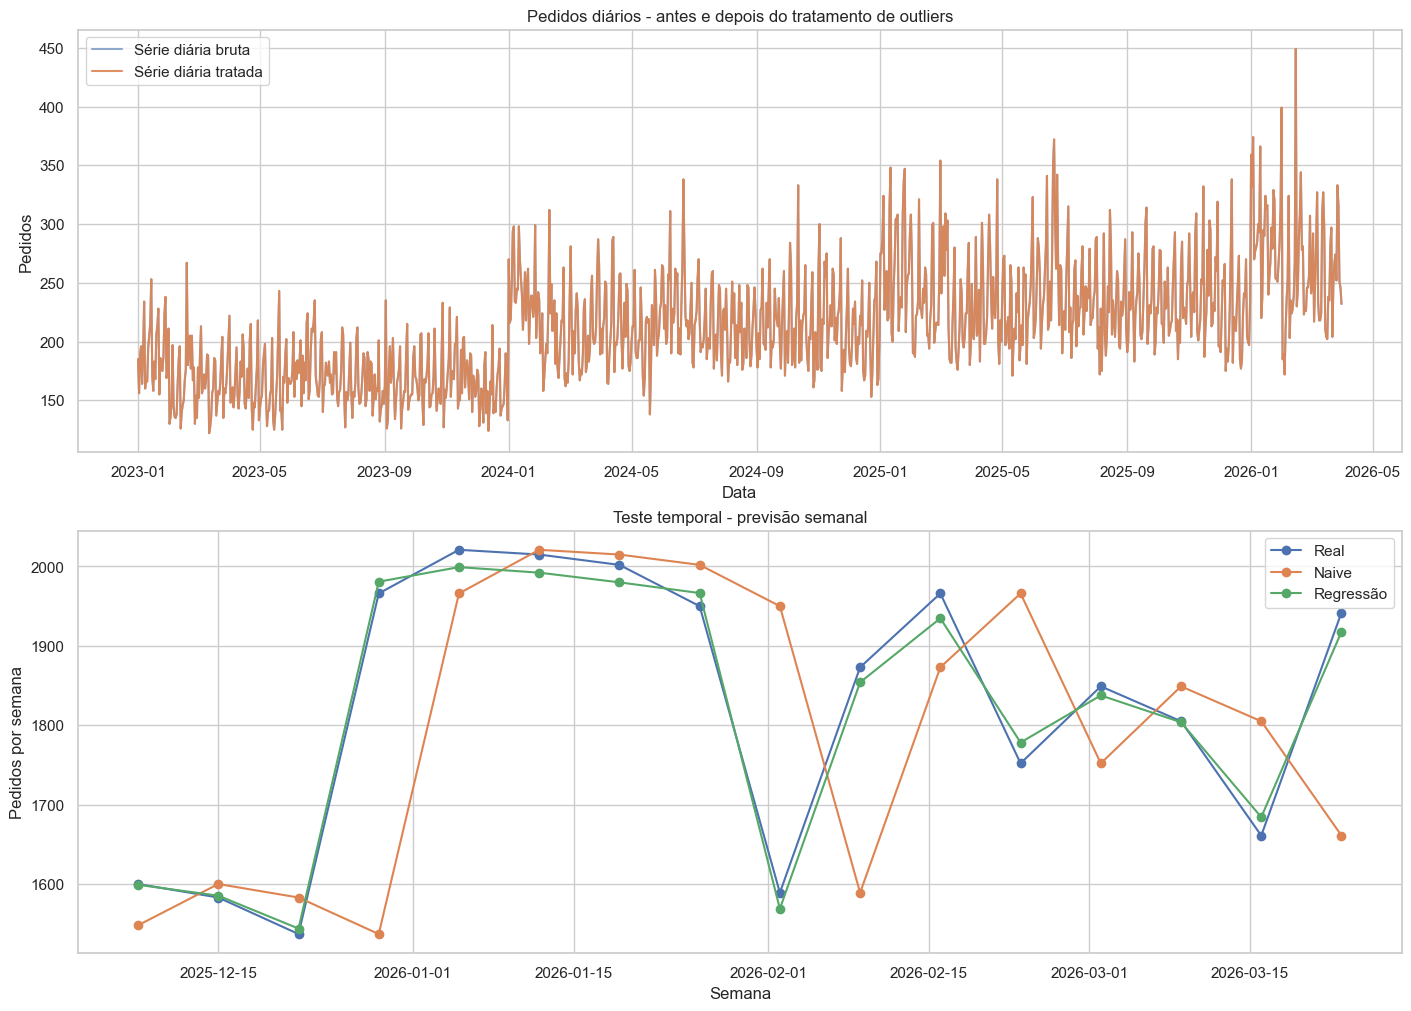

Pipeline executado com sucesso.


In [17]:
# 1) Carga e diagnóstico inicial
tabelas_raw = load_tables(CONFIG)
quality_raw = build_quality_report(tabelas_raw)
print("Relatório de qualidade (dados brutos):")
display(quality_raw)

# 2) Limpeza e normalização
tabelas_clean = normalize_tables(tabelas_raw)
quality_clean = build_quality_report(tabelas_clean)
print("Relatório de qualidade (dados tratados):")
display(quality_clean)

# 3) Base diária
diario = create_daily_frame(tabelas_clean)
print("Amostra da base diária:")
display(diario.head())

# 4) Outliers IQR + exceção temporal
diario_sem_outliers, outlier_audit, bounds = remove_outliers_iqr_with_exceptions(
    diario,
    target_col="pedidos_dia",
    event_cols=CONFIG["event_exception_cols"],
    multiplier=CONFIG["iqr_multiplier"],
)

print("Resumo dos limites de outlier:", bounds)
print("Outliers detectados:", int(outlier_audit.shape[0]))
print("Outliers removidos:", int(outlier_audit["removido"].sum()))

# 5) Base semanal + baseline
semanal = build_weekly_dataset(diario_sem_outliers)
artifacts = evaluate_baselines(semanal, test_weeks=CONFIG["test_weeks"])

print("RMSE dos baselines:")
for name, score in artifacts.rmse.items():
    print(f"- {name}: {score:.3f}")

# 6) Visualizações
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

axes[0].plot(diario["date"], diario["pedidos_dia"], label="Série diária bruta", alpha=0.6)
axes[0].plot(diario_sem_outliers["date"], diario_sem_outliers["pedidos_dia"], label="Série diária tratada", alpha=0.9)
axes[0].set_title("Pedidos diários - antes e depois do tratamento de outliers")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Pedidos")
axes[0].legend()

axes[1].plot(artifacts.test_frame["semana_inicio"], artifacts.test_frame["pedidos_semana"], marker="o", label="Real")
axes[1].plot(artifacts.test_frame["semana_inicio"], artifacts.test_frame["pred_naive"], marker="o", label="Naive")
axes[1].plot(artifacts.test_frame["semana_inicio"], artifacts.test_frame["pred_regressao"], marker="o", label="Regressão")
axes[1].set_title("Teste temporal - previsão semanal")
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("Pedidos por semana")
axes[1].legend()

plt.show()

pipeline_state = PipelineState(
    tabelas_raw=tabelas_raw,
    tabelas_clean=tabelas_clean,
    diario=diario,
    diario_sem_outliers=diario_sem_outliers,
    semanal=semanal,
    outlier_audit=outlier_audit,
    model_artifacts=artifacts,
)

print("Pipeline executado com sucesso.")

## 6. Add Basic Validation and Tests
Validações rápidas para garantir consistência de dados e comportamento esperado do pipeline.

In [18]:
# Testes de sanidade de dados
assert len(pipeline_state.tabelas_raw) == 7, "Quantidade de tabelas carregadas diferente do esperado."
assert all(df.shape[0] > 0 for df in pipeline_state.tabelas_raw.values()), "Existe tabela vazia nos dados brutos."
assert pipeline_state.diario_sem_outliers["pedidos_dia"].min() > 0, "Pedidos diários tratados contém valores inválidos."
assert pipeline_state.semanal["pedidos_semana"].isna().sum() == 0, "Target semanal possui nulos após preparação."

# Testes de consistência de modelagem
assert {"naive", "regressao"}.issubset(set(pipeline_state.model_artifacts.rmse.keys())), "Métricas RMSE incompletas."
assert all(v >= 0 for v in pipeline_state.model_artifacts.rmse.values()), "RMSE inválido (negativo)."

# Teste da regra de exceção temporal para outliers
if not pipeline_state.outlier_audit.empty:
    removed_events = pipeline_state.outlier_audit.loc[
        pipeline_state.outlier_audit["removido"],
        ["is_holiday", "is_carnaval", "is_sao_joao", "is_summer"],
    ].sum(axis=1)
    assert (removed_events == 0).all(), "Foram removidos outliers em dias de evento, contrariando a regra."

print("Todos os testes básicos foram aprovados.")

Todos os testes básicos foram aprovados.


## Conclusão Parcial
Implementação inicial concluída com pipeline modular e reprodutível.

Próximos incrementos recomendados:
1. Expandir seção de interpretação de insights de negócio.
2. Testar sensibilidade de desempenho para diferentes janelas de validação.
3. Avaliar features de estoque para enriquecer o baseline de regressão.